# Halo exchange patterns in two dimensions, forward and adjoint

`nb01` derived the adjoint of a halo exchange inside one array and `nb02` pushed it across a
process boundary — for a **one-dimensional ring** of ranks, where every block has a left and a
right neighbour and nothing else. Real decompositions are two-dimensional, and a 2-D halo has
**corners**. Corners are where the communication pattern stops being obvious, and they are the
reason the GHEX round of this project (`PLAN.md`, Round 2) restricted itself to a 1-D
decomposition: the shortcut it used for the reverse exchange is only valid without corners.

This notebook is the 2-D case, done concretely. It uses a small halo-exchange *library* written
for the purpose — pure NumPy, all ranks emulated in one process, every message an explicit
object — so that you can print the messages, transpose them by hand, and check the result
against a dense matrix, against `jax.vjp`, and finally against the single-rank shallow water
model through `jax.custom_vjp`. Nothing here requires MPI; everything maps one-to-one onto
an MPI or GHEX implementation, and section 6 says where.

The one fact everything turns on: **an interior corner cell feeds three other ranks.** Its
value is needed by the neighbour across the x face, by the neighbour across the y face, and by
the diagonal neighbour. Forward, that is a bookkeeping question — how do you deliver the
corner without sending eight messages per rank? In reverse it is a genuine constraint: three
cotangents have to come *back* to that one cell, and one buffer slot cannot carry three
different numbers.

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import inspect

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

from gt4py import next as gtx
from operators import I, J, make_periodic
from operators import timestep as gtx_timestep
from initial_conditions import initialize_interior
from adjoint_operators import interior_domain
import halo_lib as hl

timestep = gtx_timestep.definition

BLUE, ORANGE, MAGENTA = "#1f6fb4", "#d1590a", "#b03a6f"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})


def fld(domain, array):
    return gtx.as_field(domain, jnp.asarray(array, dtype=jnp.float64), allocator=jnp)


rng = np.random.default_rng(0)
print(f"jax {jax.__version__} on {jax.devices()[0]}")

jax 0.6.2 on TFRT_CPU_0


## 1. What a 2-D halo exchange has to move

Take a rank whose interior is `mloc × nloc` cells with a halo of width `h` on every side. A
nine-point stencil evaluated at the interior corner cell reads the diagonal halo cell, so the
halo that has to be filled is the full ring: four **faces** of size `h × nloc` or `mloc × h`, and
four **corners** of size `h × h`. The corner comes from the rank diagonally across.

There are two standard ways to deliver it:

- **single-phase, 8 neighbours** — every rank posts eight messages at once: four faces and four
  explicit corner messages to the diagonal ranks;
- **two-phase, 4 neighbours** — exchange the x faces first; wait; then exchange the y faces, but
  send the *whole* column including the x halos just received. The corner rides along in the
  second phase, and no rank ever addresses a diagonal neighbour.

`halo_lib.py` implements both as *patterns*: a pattern is a list of phases, a phase is a list of
messages, and a message is `(src_rank, dst_rank, src_slice, dst_slice)`. `exchange` posts every
message of a phase against the state at the start of the phase, then moves to the next phase —
`Isend`/`Irecv`/`Waitall`, phase by phase.

In [2]:
print(inspect.getsource(hl.exchange))

def exchange(blocks, pattern, log=None):
    """Fill the halos of `blocks` in place. Within a phase every message reads the state at the
    start of the phase (post all, then wait all); phases run in sequence."""
    for phase in pattern:
        packed = [(m, blocks[m.src][m.src_slice].copy()) for m in phase]
        for m, buf in packed:
            blocks[m.dst][m.dst_slice] = buf
            if log is not None:
                log.append(m)
    return blocks



### 1.1 Forward: scatter, exchange, gather

Six ranks in a `3 × 2` layout on a `12 × 12` periodic grid. Every local buffer is
`(mloc + 2, nloc + 2)`; rank `r` sits at Cartesian coordinates `(r // Ry, r % Ry)`.

In [3]:
D = hl.Decomposition(M=12, N=12, Rx=3, Ry=2, halo=1)
print(f"{D.R} ranks = {D.Rx} x {D.Ry}, local interior {D.mloc} x {D.nloc}, local buffer {D.local_shape}")
print("rank layout (px down, py across):")
for px in range(D.Rx):
    print("   ", [D.rank(px, py) for py in range(D.Ry)])

g = rng.standard_normal((D.M, D.N))
padded = np.pad(g, D.h, mode="wrap")          # what every block must look like after the exchange


def halo_error(blocks):
    errs = []
    for r, b in enumerate(blocks):
        i0, j0 = D.origin(r)
        errs.append(np.max(np.abs(b - padded[i0:i0 + D.mloc + 2 * D.h, j0:j0 + D.nloc + 2 * D.h])))
    return max(errs)


log_two, log_one = [], []
two = hl.exchange(D.scatter(g), D.two_phase_pattern(), log_two)
one = hl.exchange(D.scatter(g), D.single_phase_pattern(), log_one)

print(f"\ntwo-phase   : max |block - wrap-padded global| = {halo_error(two):.1e},  gather == global: {np.array_equal(D.gather(two), g)}")
print(f"single-phase: max |block - wrap-padded global| = {halo_error(one):.1e},  gather == global: {np.array_equal(D.gather(one), g)}")

6 ranks = 3 x 2, local interior 4 x 6, local buffer (6, 8)
rank layout (px down, py across):
    [0, 1]
    [2, 3]
    [4, 5]

two-phase   : max |block - wrap-padded global| = 0.0e+00,  gather == global: True
single-phase: max |block - wrap-padded global| = 0.0e+00,  gather == global: True


Both patterns reproduce `np.pad(g, 1, mode="wrap")` exactly, block by block. Now the messages
themselves — here every one that rank 0 sends or receives:

In [4]:
for label, log in (("two-phase", log_two), ("single-phase", log_one)):
    print(f"{label}: {len(log)} messages, {len(log) // D.R} per rank, "
          f"{sum(m.size for m in log) // D.R} elements sent per rank")
    for phase in dict.fromkeys(m.phase for m in log):
        print(f"  phase '{phase}':")
        for m in log:
            if m.phase == phase and 0 in (m.src, m.dst):
                print("     ", m)
    print()

two-phase: 24 messages, 4 per rank, 24 elements sent per rank
  phase 'x':
      rank 0 -> rank 2: [rows 4:5, cols 1:7] -> [rows 0:1, cols 1:7]
      rank 0 -> rank 4: [rows 1:2, cols 1:7] -> [rows 5:6, cols 1:7]
      rank 2 -> rank 0: [rows 1:2, cols 1:7] -> [rows 5:6, cols 1:7]
      rank 4 -> rank 0: [rows 4:5, cols 1:7] -> [rows 0:1, cols 1:7]
  phase 'y':
      rank 0 -> rank 1: [rows 0:6, cols 6:7] -> [rows 0:6, cols 0:1]
      rank 0 -> rank 1: [rows 0:6, cols 1:2] -> [rows 0:6, cols 7:8]
      rank 1 -> rank 0: [rows 0:6, cols 6:7] -> [rows 0:6, cols 0:1]
      rank 1 -> rank 0: [rows 0:6, cols 1:2] -> [rows 0:6, cols 7:8]

single-phase: 48 messages, 8 per rank, 24 elements sent per rank
  phase 'x':
      rank 0 -> rank 2: [rows 4:5, cols 1:7] -> [rows 0:1, cols 1:7]
      rank 0 -> rank 4: [rows 1:2, cols 1:7] -> [rows 5:6, cols 1:7]
      rank 2 -> rank 0: [rows 1:2, cols 1:7] -> [rows 5:6, cols 1:7]
      rank 4 -> rank 0: [rows 4:5, cols 1:7] -> [rows 0:1, cols 1:7]
  pha

Read the two-phase `y` messages: `rows 0:6` — the *entire* column, halo rows included. Rank 0's
`x` phase put rank 4's last row into rank 0's row 0; the `y` phase then ships that row 0 along
with everything else to rank 1, and rank 1's corner cell `(0, 7)` ends up holding a value that
originated on rank 4 — rank 1's diagonal neighbour — without any message between the two.

The element count is the same either way: `2h(mloc + nloc) + 4h²`. What the two-phase pattern
buys is half the messages and no diagonal neighbours to address; what it costs is a
dependency — phase `y` cannot start until phase `x` has landed. At halo sizes, latency dominates
bandwidth, so which one is faster is a machine question, not an algorithmic one. Both are in
use.

Here is rank 0's buffer after each pattern, coloured by the phase that filled each cell and
labelled with the rank the value came from:

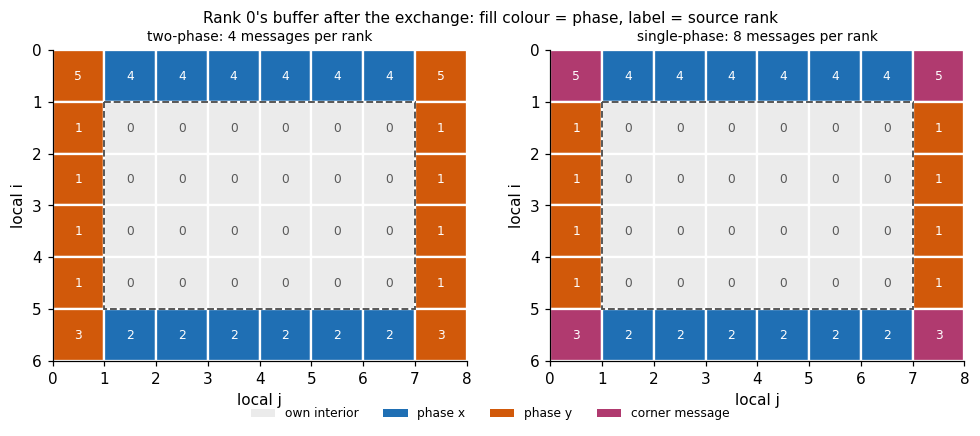

In [5]:
def buffer_map(pattern):
    ids = [np.full(D.local_shape, float(r)) for r in range(D.R)]
    log = []
    hl.exchange(ids, pattern, log)
    phase = np.full(D.local_shape, "own", dtype=object)
    for m in log:
        if m.dst == 0:
            phase[m.dst_slice] = m.phase
    return ids[0], phase


colors = {"own": "0.92", "x": BLUE, "y": ORANGE, "corner": MAGENTA}
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.9))
for ax, (title, pattern) in zip(axes, [("two-phase: 4 messages per rank", D.two_phase_pattern()),
                                       ("single-phase: 8 messages per rank", D.single_phase_pattern())]):
    src, phase = buffer_map(pattern)
    for i in range(D.local_shape[0]):
        for j in range(D.local_shape[1]):
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fc=colors[phase[i, j]], ec="white", lw=1.5))
            ax.text(j + 0.5, i + 0.5, f"{int(src[i, j])}", ha="center", va="center", fontsize=8,
                    color="white" if phase[i, j] != "own" else "0.35")
    ax.add_patch(plt.Rectangle((D.h, D.h), D.nloc, D.mloc, fill=False, ec="0.3", lw=1.2, ls="--"))
    ax.set_xlim(0, D.local_shape[1]); ax.set_ylim(D.local_shape[0], 0)
    ax.set_aspect("equal"); ax.grid(False)
    ax.set_xlabel("local j"); ax.set_ylabel("local i")
    ax.set_title(title, fontsize=9)
handles = [plt.Rectangle((0, 0), 1, 1, fc=c) for c in colors.values()]
fig.legend(handles, ["own interior", "phase x", "phase y", "corner message"], loc="lower center",
           ncol=4, frameon=False, fontsize=8, bbox_to_anchor=(0.5, 0.0))
fig.suptitle("Rank 0's buffer after the exchange: fill colour = phase, label = source rank", fontsize=10)
fig.tight_layout(rect=(0, 0.09, 1, 1))
plt.show()

Same final contents, same source ranks — the corners come from ranks 5 and 3, rank 0's diagonal
neighbours, in both panels — delivered through different phases. In the two-phase panel the
corner cells are `y`-coloured: they arrived in the second phase, carried inside the extended
column, and the value is the one rank 1's own `x` phase had just deposited in *its* halo row.

## 2. The transpose, three ways

The exchange is a linear map that moves numbers without changing them, so its Jacobian is a
0/1 matrix and its adjoint is that matrix transposed (`nb01` §3–5). Three independent
constructions of that transpose should agree to roundoff:

1. build the dense matrix `A` of the exchange for a tiny decomposition and apply `A.T`;
2. `halo_lib.exchange_adjoint`: the transposition rule applied message by message;
3. re-implement the forward exchange in `jax.numpy` and let `jax.vjp` transpose it.

### 2.1 The dense matrix

A `6 × 6` grid on `2 × 2` ranks: four buffers of `5 × 5`, so `A` is `100 × 100`.

In [6]:
D6 = hl.Decomposition(M=6, N=6, Rx=2, Ry=2, halo=1)
A = hl.exchange_matrix(D6, D6.two_phase_pattern())
A_single = hl.exchange_matrix(D6, D6.single_phase_pattern())

print(f"A: {A.shape}, {int(A.sum())} non-zeros")
print(f"two-phase and single-phase give the same matrix: {np.array_equal(A, A_single)}")
print(f"row sums of A    (sources per output slot): {np.unique(A.sum(axis=1)).astype(int)}")
print(f"column sums of A (slots fed per input slot): {np.unique(A.sum(axis=0)).astype(int)}")

fan_out = A.sum(axis=0).reshape(D6.R, *D6.local_shape)
print("\nrank 0: how many slots each input cell feeds (itself included)")
print(fan_out[0].astype(int))

A: (100, 100), 100 non-zeros
two-phase and single-phase give the same matrix: True
row sums of A    (sources per output slot): [1]
column sums of A (slots fed per input slot): [0 1 2 4]

rank 0: how many slots each input cell feeds (itself included)
[[0 0 0 0 0]
 [0 4 2 4 0]
 [0 2 1 2 0]
 [0 4 2 4 0]
 [0 0 0 0 0]]


Every row of `A` has exactly one `1`: each output slot is a copy of exactly one input cell. The
columns are the transpose story. A halo cell feeds nothing (column sum 0 — its cotangent must be
zeroed). An interior cell away from the edge feeds only itself. An **edge** cell feeds itself
plus one halo slot on the neighbour across that face. An interior **corner** cell feeds itself
plus **three** halo slots, on three different ranks. Column sums of `A` are row sums of `A.T`:
they count how many cotangents each cell has to *collect*. Four, for a corner.

The single-phase and two-phase patterns produce the identical matrix — as they must, since they
produce identical buffers — so they have the identical transpose. What differs is how that
transpose is *scheduled*, which is section 2.2.

In [7]:
y6 = [rng.standard_normal(D6.local_shape) for _ in range(D6.R)]
ATy = (A.T @ np.stack(y6).ravel()).reshape(D6.R, *D6.local_shape)
adj6 = np.stack(hl.exchange_adjoint([b.copy() for b in y6], D6.two_phase_pattern()))
print(f"max |A.T @ y - exchange_adjoint(y)| = {np.max(np.abs(ATy - adj6)):.2e}")

max |A.T @ y - exchange_adjoint(y)| = 2.22e-16


### 2.2 The transposition rule, message by message

`exchange_adjoint` is `nb01`'s dictionary applied to a pattern: phases in reverse order, every
message reversed (`dst → src`), assignment replaced by accumulation into the owner, and the
halo cotangent zeroed once it has been sent. Note what "phases in reverse" means for the
two-phase pattern: the `y` phase is transposed **first**, so a corner cotangent travels back
along the extended column and lands in the y neighbour's *x halo row* — from where the
transposed `x` phase carries it on to its owner. The corner path is reversed by reversing the
phases; nothing special is done for corners.

In [8]:
print(inspect.getsource(hl.exchange_adjoint))

def exchange_adjoint(blocks_bar, pattern, accumulate=True, zero_halo=True):
    """Transpose of `exchange` with the same pattern, in place.

    Phases in reverse order, every message reversed (dst -> src), assignment replaced by
    accumulation into the owner, and the halo cotangent zeroed once it has been sent.
    The two keyword switches exist only to reproduce the classic mistakes."""
    for phase in reversed(pattern):
        packed = [(m, blocks_bar[m.dst][m.dst_slice].copy()) for m in phase]
        if zero_halo:
            for m, _ in packed:
                blocks_bar[m.dst][m.dst_slice] = 0.0
        for m, buf in packed:
            if accumulate:
                blocks_bar[m.src][m.src_slice] += buf
            else:
                blocks_bar[m.src][m.src_slice] = buf
    return blocks_bar



### 2.3 `jax.vjp` of a `jnp` re-implementation

Write the same forward exchange on a stacked `(R, mloc + 2, nloc + 2)` array with `jnp` slicing
and `.at[].set()` — the emulated-rank style of `nb02`'s `exchange_transparent` — and ask JAX for
the transpose. Back on the `3 × 2` decomposition:

In [9]:
def exchange_jnp(stacked, pattern):
    for phase in pattern:
        packed = [(m, stacked[m.src][m.src_slice]) for m in phase]      # read the phase-start state
        for m, buf in packed:
            stacked = stacked.at[(m.dst,) + m.dst_slice].set(buf)
    return stacked


PATTERN = D.two_phase_pattern()
x = [rng.standard_normal(D.local_shape) for _ in range(D.R)]
y = [rng.standard_normal(D.local_shape) for _ in range(D.R)]

Lx_lib = np.stack(hl.exchange([b.copy() for b in x], PATTERN))
Lx_jnp, vjp = jax.vjp(lambda s: exchange_jnp(s, PATTERN), jnp.asarray(np.stack(x)))
(ct_jax,) = vjp(jnp.asarray(np.stack(y)))
ct_lib = np.stack(hl.exchange_adjoint([b.copy() for b in y], PATTERN))

lhs = float(np.sum(Lx_lib * np.stack(y)))
rhs = float(np.sum(np.stack(x) * ct_lib))
print(f"forward:  max |jnp - library|            = {np.max(np.abs(np.asarray(Lx_jnp) - Lx_lib)):.2e}")
print(f"adjoint:  max |jax.vjp - exchange_adjoint| = {np.max(np.abs(np.asarray(ct_jax) - ct_lib)):.2e}")
print(f"\ndot-product test on exchange_adjoint:")
print(f"  <Lx, y>    = {lhs:.16e}")
print(f"  <x, L^T y> = {rhs:.16e}")
print(f"  relative   = {abs(lhs - rhs) / abs(lhs):.2e}")

forward:  max |jnp - library|            = 0.00e+00
adjoint:  max |jax.vjp - exchange_adjoint| = 0.00e+00

dot-product test on exchange_adjoint:
  <Lx, y>    = 1.7139785703166881e+00
  <x, L^T y> = 1.7139785703166925e+00
  relative   = 2.59e-15


Three constructions, one transpose. The hand-written rule is bit-identical to what JAX derives,
and the dot-product test holds at roundoff.

## 3. The scratch-buffer trick, and why it needs a ring

Now the reason this notebook exists. When the reverse exchange has to run on a real
communication library, there is a very tempting shortcut: **do not write a reverse pattern at
all**. Take a zero scratch buffer, copy each halo cotangent into the interior cell just across
the block boundary, run the ordinary *forward* exchange on the scratch buffer, and read the
result back out of the halo slots on the far side. The forward pattern carries the cotangent
"backwards" because the pattern is symmetric — for every message `A → B` there is a mirror
message `B → A`, and the mirror message reads exactly where the trick placed the data.

This is what the GHEX round of this project did (`PLAN.md`, Round 2), and it is why that round
chose a 1-D decomposition. Here is the trick, written against the same pattern objects:

In [10]:
print(inspect.getsource(hl.exchange_adjoint_scratch))

def exchange_adjoint_scratch(decomp, blocks_bar, pattern):
    """The 'scratch-buffer trick': carry halo cotangents backwards with the FORWARD exchange.

    Reflect every halo cotangent into the interior cell across the block boundary, run the
    ordinary forward exchange on that scratch buffer, and read the result back from the halo
    slots on the other side. Exact when every interior slot feeds a single neighbour, i.e. a
    1-D ring with mloc >= 2h. Wrong on thinner blocks, and wrong in 2-D, where a corner cell
    feeds three."""
    scratch = [np.zeros_like(b) for b in blocks_bar]
    for phase in pattern:
        for m in phase:
            scratch[m.dst][_reflect(decomp, m.dst_slice)] += blocks_bar[m.dst][m.dst_slice]
    exchange(scratch, pattern)
    for phase in pattern:
        for m in phase:
            blocks_bar[m.dst][m.dst_slice] = 0.0
    for phase in pattern:
        for m in phase:
            blocks_bar[m.src][m.src_slice] += scratch[m.src][_reflect(decomp, m.s

### 3.1 On a ring it is exact

A 1-D decomposition along `x` — four ranks, each owning `3 × 12` — exchanges only the two `x`
faces; the `y` direction is not decomposed, so its periodicity is the model's business (a local
`concat_where`, as in `nb02`'s `periodic_j`). The trick against the true transpose — and then
the same trick on a ring of *single-row* blocks (`mloc = h`), where the one interior row is sent
to both neighbours:

In [11]:
def compare_adjoints(decomp, pattern, label):
    x = [rng.standard_normal(decomp.local_shape) for _ in range(decomp.R)]
    y = [rng.standard_normal(decomp.local_shape) for _ in range(decomp.R)]
    Lx = hl.exchange([b.copy() for b in x], pattern)
    lhs = sum(np.sum(a * b) for a, b in zip(Lx, y))
    true = hl.exchange_adjoint([b.copy() for b in y], pattern)
    trick = hl.exchange_adjoint_scratch(decomp, [b.copy() for b in y], pattern)
    err = np.abs(np.stack(trick) - np.stack(true))
    for name, ct in (("reversed pattern", true), ("scratch trick", trick)):
        rhs = sum(np.sum(a * b) for a, b in zip(x, ct))
        print(f"{label} | {name:17s}: dot-product rel. error {abs(lhs - rhs) / abs(lhs):9.2e}")
    print(f"{label} | max |trick - true| = {err.max():.2e}, wrong cells: {int((err > 1e-12).sum())} of {err.size}"
          f" ({int((err[0] > 1e-12).sum())} per rank)")
    return err


D_ring = hl.Decomposition(M=12, N=12, Rx=4, Ry=1, halo=1)
err_ring = compare_adjoints(D_ring, D_ring.ring_pattern(), "1-D ring (4 x 1)  ")
print()
D_thin = hl.Decomposition(M=4, N=12, Rx=4, Ry=1, halo=1)          # mloc = 1 = h
err_thin = compare_adjoints(D_thin, D_thin.ring_pattern(), "1-D ring, mloc = h")

1-D ring (4 x 1)   | reversed pattern : dot-product rel. error  1.46e-16
1-D ring (4 x 1)   | scratch trick    : dot-product rel. error  1.46e-16
1-D ring (4 x 1)   | max |trick - true| = 0.00e+00, wrong cells: 0 of 280 (0 per rank)

1-D ring, mloc = h | reversed pattern : dot-product rel. error  0.00e+00
1-D ring, mloc = h | scratch trick    : dot-product rel. error  3.80e+00
1-D ring, mloc = h | max |trick - true| = 5.36e+00, wrong cells: 48 of 168 (12 per rank)


Exact to the last bit on the `3 × 12` blocks: no reverse pattern was written and the dot-product
test passes. On single-row blocks it fails — dot-product error 3.8, every interior cell of every
rank wrong — because the condition behind the trick is not "ring" but *every interior slot feeds
exactly one neighbour*. With `mloc < 2h` the rows sent left and the rows sent right overlap, and
one slot again has to carry two cotangents. `3 × 12` satisfies `mloc ≥ 2h`, and so do the
shallow-water blocks of section 5.

### 3.2 In two dimensions it is wrong

Same trick, same code, on the `3 × 2` decomposition with the two-phase pattern:

In [12]:
err_2d = compare_adjoints(D, PATTERN, "2-D (3 x 2)      ")
print()
print("rank 0, cells where the trick differs from the transpose (1 = wrong):")
print((err_2d[0] > 1e-12).astype(int))

2-D (3 x 2)       | reversed pattern : dot-product rel. error  4.26e-16
2-D (3 x 2)       | scratch trick    : dot-product rel. error  2.42e+00
2-D (3 x 2)       | max |trick - true| = 3.92e+00, wrong cells: 48 of 288 (8 per rank)

rank 0, cells where the trick differs from the transpose (1 = wrong):
[[0 1 0 0 0 0 1 0]
 [0 1 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 1 0]
 [0 1 0 0 0 0 1 0]]


An error of order one in the dot-product test, and it is not a subtle one — but it is
*localised*. Every face cell is right; only the cells around the four corners are wrong: the
interior corner cell itself and, in the two-phase pattern, the halo-row cell next to it.

### 3.3 The mechanism: one slot, three cotangents

Seed a single unit of cotangent in one halo cell of rank 0 and ask both adjoints where it lands.

In [13]:
def seed(r, i, j):
    g = [np.zeros(D.local_shape) for _ in range(D.R)]
    g[r][i, j] = 1.0
    return g


def landing(blocks):
    return [f"rank {r} {tuple(int(k) for k in idx)}: {blocks[r][tuple(idx)]:+.0f}"
            for r in range(D.R) for idx in np.argwhere(np.abs(blocks[r]) > 0)]


px, py = D.coords(0)
print(f"rank 0's neighbours: x = {D.rank(px - 1, py)} / {D.rank(px + 1, py)}, "
      f"y = {D.rank(px, py - 1)} / {D.rank(px, py + 1)}, diagonal (-1,-1) = {D.rank(px - 1, py - 1)}\n")
for label, (i, j) in [("corner halo (0, 0)", (0, 0)),
                      ("x-face halo next to the corner (0, 1)", (0, 1)),
                      ("x-face halo mid-face (0, 3)", (0, 3))]:
    print(f"unit cotangent at rank 0, {label}")
    print(f"   reversed pattern -> {landing(hl.exchange_adjoint(seed(0, i, j), PATTERN))}")
    print(f"   scratch trick    -> {landing(hl.exchange_adjoint_scratch(D, seed(0, i, j), PATTERN))}")

rank 0's neighbours: x = 4 / 2, y = 1 / 1, diagonal (-1,-1) = 5

unit cotangent at rank 0, corner halo (0, 0)
   reversed pattern -> ['rank 5 (4, 6): +1']
   scratch trick    -> []
unit cotangent at rank 0, x-face halo next to the corner (0, 1)
   reversed pattern -> ['rank 4 (4, 1): +1']
   scratch trick    -> ['rank 1 (1, 6): +1', 'rank 4 (4, 1): +1', 'rank 5 (5, 6): +1']
unit cotangent at rank 0, x-face halo mid-face (0, 3)
   reversed pattern -> ['rank 4 (4, 3): +1']
   scratch trick    -> ['rank 4 (4, 3): +1']


Mid-face, the trick is correct: the cotangent of halo `(0, 3)` belongs to rank 4's last interior
row, and that is where both adjoints put it. The two other seeds show the two ways it breaks:

- **The corner cotangent is lost.** Halo `(0, 0)` is a `y`-phase destination, so the trick
  reflects it across the `y` face — into `(0, 1)`, which is a *halo row* of the scratch buffer.
  The forward `x` phase then overwrites that row before the `y` phase could send it. The true
  transpose delivers it to rank 5's interior corner `(4, 6)`; the trick delivers it nowhere.
- **The corner-adjacent face cotangent is delivered three times.** Halo `(0, 1)` reflects into
  the interior corner slot `(1, 1)`, and the forward exchange fans that slot out exactly as it
  fans out a real corner value: the `x` message carries it to rank 4 `(4, 1)` — correct — the
  extended `y` message carries it to rank 1 `(1, 6)` — wrong — and rank 4's `y` phase forwards
  its freshly filled halo row on to rank 5 `(5, 6)`, a halo cell of the diagonal rank — wrong
  again, and the source of the halo-row errors in the map above. The y-face halo `(1, 0)`
  reflects into the same slot and suffers the mirror-image fate.

Both are the same fact seen from two sides. Section 2.1 counted it: the interior corner cell
feeds three halo slots on three ranks, so in reverse it must *collect* three cotangents from
three ranks — one from each face neighbour and one from the diagonal. The trick has one scratch
slot per interior cell and one forward pattern to run, so whatever is in the corner slot goes to
all three, and a cotangent that belongs to one of them arrives at all three while the one that
belongs to the diagonal never enters the interior at all. On a ring with `mloc ≥ 2h` every edge
cell is read by exactly one message, the fan-out is one, and the trick is exact; that condition is
the whole content of the trick, which is why it fails on single-row blocks in 1-D (section 3.1)
exactly as it fails at corners in 2-D.

This is precisely the reason the GHEX round decomposed in one dimension only: there, the
exchange has no corners and the trick is the transpose. In 2-D the reverse exchange has to be
a real reverse pattern — phases reversed, messages reversed, accumulate, zero — and that is
what `exchange_adjoint` is. It passed the same test above at roundoff.

## 4. The two classic bugs, in 2-D

`nb01` §10 showed the two mistakes people make in hand-written halo adjoints — assigning instead
of accumulating, and forgetting to zero the halo cotangent — inside one `concat_where` operator.
Here they are as one-line changes to the library's reverse exchange (`accumulate=False`,
`zero_halo=False`), on the `3 × 2` decomposition, caught by the same dot-product test.

In [14]:
variants = [("correct", {}),
            ("no accumulation", {"accumulate": False}),
            ("no zeroing", {"zero_halo": False}),
            ("scratch trick", None)]

print(f"{'variant':>16} | {'<x, L^T y>':>20} | {'rel. error':>10} | {'max diff vs correct':>19}")
print("-" * 76)
for name, kw in variants:
    if kw is None:
        ct = hl.exchange_adjoint_scratch(D, [b.copy() for b in y], PATTERN)
    else:
        ct = hl.exchange_adjoint([b.copy() for b in y], PATTERN, **kw)
    r = float(np.sum(np.stack(x) * np.stack(ct)))
    d = float(np.max(np.abs(np.stack(ct) - ct_lib)))
    print(f"{name:>16} | {r:20.12e} | {abs(lhs - r) / abs(lhs):10.2e} | {d:19.2e}")
print(f"\nreference <Lx, y> = {lhs:.12e}")

         variant |           <x, L^T y> | rel. error | max diff vs correct
----------------------------------------------------------------------------
         correct |   1.713978570317e+00 |   2.59e-15 |            0.00e+00
 no accumulation |   1.107259190697e+01 |   5.46e+00 |            4.36e+00
      no zeroing |  -7.105577446399e+00 |   5.15e+00 |            3.23e+00
   scratch trick |   5.670946055747e+00 |   2.31e+00 |            3.41e+00

reference <Lx, y> = 1.713978570317e+00


Three wrong adjoints, three loud failures, and one of them is the shortcut of section 3. In a
2-D code the dot-product test on the exchange alone — random `x`, random `y`, one forward, one
reverse — costs nothing and catches every one of these. It should be the first test any
distributed adjoint runs.

## 5. A real 2-D model through it

The shallow water model of `nb01`, distributed over `2 × 2` ranks with **no** `periodic_j`:
periodicity in both directions now comes from the exchange. Each rank runs the unmodified
`operators.timestep` on its own block as a GT4Py field on the local halo domain, and the
exchange between steps is `halo_lib.exchange` behind `jax.pure_callback`, wrapped in
`jax.custom_vjp` with `halo_lib.exchange_adjoint` as the backward pass — `nb02`'s Route B, with
the emulated library standing in for MPI.

Two details are worth stating. `timestep` ends in `make_periodic`, which on a local block writes
a *locally* periodic halo — wrong values, which the exchange then overwrites. That is exactly the
halo→halo framing of `nb01` §8: the exchange discards whatever was in the halo, and the adjoint's
zeroing is what makes those discarded values carry no gradient. And only `u`, `v`, `p` are
exchanged: the `uold`, `vold`, `pold` halos are never read by the stencils.

### 5.1 The single-rank reference

In [15]:
M = N = 16
dx = dy = 100000.0
dt, radius, alpha = 90.0, 1000000.0, 0.001
N_STEPS = 5
DOM_INT = interior_domain(M, N)


def reference_forward(u0, v0, p0, n_steps):
    u, v, p = (make_periodic(fld(DOM_INT, a), M, N) for a in (u0, v0, p0))
    state = timestep(u, v, p, dx, dy, dt, u, v, p, 0.0, M, N)

    def step(carry, _):
        u, v, p, uo, vo, po = carry
        return timestep(u, v, p, dx, dy, 2.0 * dt, uo, vo, po, alpha, M, N), None

    final, _ = jax.lax.scan(step, state, None, length=n_steps - 1)
    return tuple(f.ndarray[1:-1, 1:-1] for f in final[:3])        # interior only


def J_ref(u0, v0, p0):
    return sum(jnp.sum(a ** 2) for a in reference_forward(u0, v0, p0, N_STEPS))


_u, _v, _p = initialize_interior(np, M, N, dx, dy, radius)
state0 = tuple(jnp.asarray(a) for a in (_u, _v, _p))
ref_uvp = reference_forward(*state0, N_STEPS)
print("reference state after", N_STEPS, "steps:", [a.shape for a in ref_uvp])

reference state after 5 steps: [(16, 16), (16, 16), (16, 16)]


### 5.2 The distributed model

The exchange is opaque to JAX, so `custom_vjp` supplies its transpose. Everything else —
scatter, gather, the local `timestep` calls — is ordinary traceable code that JAX differentiates
on its own.

In [16]:
DS = hl.Decomposition(M, N, Rx=2, Ry=2, halo=1)
DOM_L = gtx.domain({I: (-1, DS.mloc + 1), J: (-1, DS.nloc + 1)})


def make_exchange(pattern, adjoint=hl.exchange_adjoint, **adjoint_kw):
    def _fwd_np(stacked):
        return np.stack(hl.exchange(hl.unstack(np.asarray(stacked)), pattern))

    def _bwd_np(g):
        return np.stack(adjoint(hl.unstack(np.asarray(g)), pattern, **adjoint_kw))

    @jax.custom_vjp
    def exchange(stacked):
        return jax.pure_callback(_fwd_np, jax.ShapeDtypeStruct(stacked.shape, stacked.dtype), stacked)

    exchange.defvjp(lambda s: (exchange(s), None),
                    lambda _, g: (jax.pure_callback(_bwd_np, jax.ShapeDtypeStruct(g.shape, g.dtype), g),))
    return exchange


exchange_2d = make_exchange(DS.two_phase_pattern())


def scatter(a):
    return jnp.stack([jnp.pad(a[i0:i0 + DS.mloc, j0:j0 + DS.nloc], DS.h)
                      for i0, j0 in (DS.origin(r) for r in range(DS.R))])


def gather(stacked):
    rows = [jnp.concatenate([stacked[DS.rank(px, py), 1:-1, 1:-1] for py in range(DS.Ry)], axis=1)
            for px in range(DS.Rx)]
    return jnp.concatenate(rows, axis=0)


def local_steps(stacks, dt_, alpha_):
    per_rank = []
    for r in range(DS.R):
        u, v, p, uo, vo, po = (fld(DOM_L, s[r]) for s in stacks)
        per_rank.append([f.ndarray for f in timestep(u, v, p, dx, dy, dt_, uo, vo, po, alpha_, DS.mloc, DS.nloc)])
    return [jnp.stack([per_rank[r][k] for r in range(DS.R)]) for k in range(6)]


def distributed_forward(u0, v0, p0, n_steps, exchange=exchange_2d, scan=True):
    u, v, p = (exchange(scatter(a)) for a in (u0, v0, p0))
    u, v, p, uo, vo, po = local_steps((u, v, p, u, v, p), dt, 0.0)
    u, v, p = (exchange(a) for a in (u, v, p))

    def step(carry, _):
        u, v, p, uo, vo, po = local_steps(carry, 2.0 * dt, alpha)
        u, v, p = (exchange(a) for a in (u, v, p))
        return (u, v, p, uo, vo, po), None

    state = (u, v, p, uo, vo, po)
    if scan:
        state, _ = jax.lax.scan(step, state, None, length=n_steps - 1)
    else:
        for _ in range(n_steps - 1):
            state, _ = step(state, None)
    return state[:3]


def J_dist(u0, v0, p0, exchange=exchange_2d):
    return sum(jnp.sum(a[:, 1:-1, 1:-1] ** 2) for a in distributed_forward(u0, v0, p0, N_STEPS, exchange))


dist_uvp = distributed_forward(*state0, N_STEPS)
for name, a, b in zip("uvp", ref_uvp, dist_uvp):
    print(f"forward {name}: max |distributed - reference| = {float(jnp.max(jnp.abs(gather(b) - a))):.2e}"
          f"   (max |{name}| = {float(jnp.max(jnp.abs(a))):.2e})")

forward u: max |distributed - reference| = 0.00e+00   (max |u| = 3.84e+00)
forward v: max |distributed - reference| = 0.00e+00   (max |v| = 3.84e+00)
forward p: max |distributed - reference| = 0.00e+00   (max |p| = 5.00e+04)


`jax.pure_callback` under `jax.lax.scan` works as it should here, so the time loop is a `scan`
as in `nb01`. The distributed forward reproduces the single-rank model **bit for bit**: the
per-cell arithmetic is identical, and the only thing the decomposition changes is where each halo
value comes from.

That `0.0` is a same-compilation-path statement. Both models run their time loop under
`lax.scan`, so XLA fuses the same arithmetic the same way. Run the identical distributed code as
an eager Python loop instead and it differs from its own `scan` version:

In [17]:
loop_uvp = distributed_forward(*state0, N_STEPS, scan=False)
for name, a, b in zip("uvp", dist_uvp, loop_uvp):
    print(f"eager loop vs scan, {name}: max difference {float(jnp.max(jnp.abs(a - b))):.2e}")

eager loop vs scan, u: max difference 4.44e-16
eager loop vs scan, v: max difference 4.44e-16
eager loop vs scan, p: max difference 7.28e-12


`4 × 10⁻¹⁶` in `u` and `v`, `7 × 10⁻¹²` in `p` — roundoff, larger in `p` because `p` is larger.
"Bit-identical" means the same compiled arithmetic on the same platform and nothing more; the
stored numbers in this notebook are CPU numbers by construction, since `JAX_PLATFORMS` is pinned
in the first cell.

### 5.3 Corners are not optional

The SWM stencils read `p(I+1)(J+1)`-type neighbours — `avg_x(avg_y(p))`,
`avg_y_staggered(avg_x(cv))` — so the corner halo cells are genuinely consumed. Run the same
model with a **faces-only** pattern, four messages per rank and no corners:

In [18]:
exchange_faces = make_exchange(DS.faces_only_pattern())
nc_uvp = distributed_forward(*state0, N_STEPS, exchange=exchange_faces)
nc1_uvp = distributed_forward(*state0, 1, exchange=exchange_faces)
ref1_uvp = reference_forward(*state0, 1)
for name, a, b, a1, b1 in zip("uvp", ref_uvp, nc_uvp, ref1_uvp, nc1_uvp):
    e1 = np.abs(np.asarray(gather(b1) - a1))
    print(f"faces only, {name}: max error after 1 step {e1.max():.2e} in {int((e1 > 0).sum())} cells, "
          f"after {N_STEPS} steps {float(jnp.max(jnp.abs(gather(b) - a))):.2e}")

faces only, u: max error after 1 step 3.95e-04 in 8 cells, after 5 steps 2.59e-04
faces only, v: max error after 1 step 3.95e-04 in 8 cells, after 5 steps 2.59e-04
faces only, p: max error after 1 step 0.00e+00 in 0 cells, after 5 steps 4.23e-04


Wrong, and wrong in the way that is dangerous. After one step the damage is 8 cells of `u` and
8 of `v` next to the block corners — `p`'s first update happens not to read a diagonal — and
after five steps it has spread to every field. An error of `10⁻⁴` on fields of order one is
invisible in a contour plot, against the `0.0` of the correct exchange on the same code path. This is a bug only a reference comparison finds, and the reason an "obviously fine"
exchange still needs to be validated against a single-rank run.

### 5.4 The gradient

A scalar cost, `J = Σ (u² + v² + p²)` over the interior after five steps, differentiated with
respect to the initial state: `jax.grad` through six `custom_vjp` exchanges per field — the
initial fill and one per step — against `jax.grad` through six `make_periodic` operators per
field on one rank.

In [19]:
J0_ref = float(J_ref(*state0))
grad_ref = jax.grad(J_ref, argnums=(0, 1, 2))(*state0)
J0 = float(J_dist(*state0))
grad_dist = jax.grad(J_dist, argnums=(0, 1, 2))(*state0)

print(f"J reference  = {J0_ref:.15e}")
print(f"J distributed= {J0:.15e}    relative difference {abs(J0 - J0_ref) / abs(J0_ref):.2e}\n")
for name, a, b in zip("uvp", grad_ref, grad_dist):
    d = float(jnp.max(jnp.abs(a - b)))
    print(f"grad {name}: max |distributed - reference| = {d:.2e}   relative to max |grad| {d / float(jnp.max(jnp.abs(a))):.2e}")

J reference  = 6.400000051658011e+11
J distributed= 6.400000051658011e+11    relative difference 0.00e+00

grad u: max |distributed - reference| = 6.41e-09   relative to max |grad| 5.78e-12
grad v: max |distributed - reference| = 6.42e-09   relative to max |grad| 5.79e-12
grad p: max |distributed - reference| = 5.82e-11   relative to max |grad| 5.82e-16


The cost is identical and the gradients agree to `6 × 10⁻¹²` relative for `u` and `v` and
`6 × 10⁻¹⁶` for `p`. The `u`/`v` residual is not the exchange, it is cancellation: the cost is
dominated by `p` (of order `5 × 10⁴`), so the `p` cotangents that flow into the `u` and `v`
gradients are of order `10⁵` while those gradients themselves are of order `10³`, and any
change in summation order shows up at `10⁻¹²` relative. Two checks make that concrete — two
*exact* transposes that differ only in summation order (the two-phase and single-phase adjoints),
and a cost with `p` left out:

In [20]:
exchange_1p = make_exchange(DS.single_phase_pattern())
grad_1p = jax.grad(lambda a, b, c: J_dist(a, b, c, exchange=exchange_1p), argnums=(0, 1, 2))(*state0)
for name, a, b in zip("uvp", grad_dist, grad_1p):
    print(f"two-phase vs single-phase adjoint, grad {name}: relative "
          f"{float(jnp.max(jnp.abs(a - b)) / jnp.max(jnp.abs(a))):.2e}")


def J_uv_ref(u0, v0, p0):
    u, v, _ = reference_forward(u0, v0, p0, N_STEPS)
    return jnp.sum(u ** 2) + jnp.sum(v ** 2)


def J_uv_dist(u0, v0, p0):
    u, v, _ = distributed_forward(u0, v0, p0, N_STEPS)
    return jnp.sum(u[:, 1:-1, 1:-1] ** 2) + jnp.sum(v[:, 1:-1, 1:-1] ** 2)


g_uv_ref = jax.grad(J_uv_ref, argnums=(0, 1, 2))(*state0)
g_uv_dist = jax.grad(J_uv_dist, argnums=(0, 1, 2))(*state0)
for name, a, b in zip("uvp", g_uv_ref, g_uv_dist):
    print(f"cost on u and v only, grad {name}: relative "
          f"{float(jnp.max(jnp.abs(a - b)) / jnp.max(jnp.abs(a))):.2e}")

two-phase vs single-phase adjoint, grad u: relative 1.92e-12
two-phase vs single-phase adjoint, grad v: relative 4.38e-12
two-phase vs single-phase adjoint, grad p: relative 2.91e-16


cost on u and v only, grad u: relative 5.79e-16
cost on u and v only, grad v: relative 5.79e-16
cost on u and v only, grad p: relative 4.78e-14


Two exact transposes differ by `2–4 × 10⁻¹²` in the `u` and `v` gradients — the size of the
residual against the reference — and with `p` out of the cost the `u`/`v` gradients agree to
`6 × 10⁻¹⁶`. The residual is arithmetic, not a wrong message. Now the same gradient with the three wrong backward passes of sections 3 and 4
wired into `custom_vjp` — same forward, only `_bwd_np` differs:

In [21]:
wrong = [("no accumulation", make_exchange(DS.two_phase_pattern(), accumulate=False)),
         ("no zeroing", make_exchange(DS.two_phase_pattern(), zero_halo=False)),
         ("scratch trick", make_exchange(DS.two_phase_pattern(),
                                         adjoint=lambda g, pat: hl.exchange_adjoint_scratch(DS, g, pat)))]
for label, ex in wrong:
    gb = jax.grad(lambda a, b, c: J_dist(a, b, c, exchange=ex), argnums=(0, 1, 2))(*state0)
    rel = max(float(jnp.max(jnp.abs(a - b)) / jnp.max(jnp.abs(a))) for a, b in zip(grad_ref, gb))
    print(f"{label:>16}: max relative gradient error {rel:.2e}")

 no accumulation: max relative gradient error 1.73e+04


      no zeroing: max relative gradient error 6.36e+03


   scratch trick: max relative gradient error 3.62e+04


Not percent-level errors — orders of magnitude. Five steps of leapfrog compound each exchange's
mistake through the stencils, and the pressure field's magnitude (`5 × 10⁴`) amplifies whatever
leaks. A minimiser handed any of these gradients would not converge slowly; it would go
somewhere else.

### 5.5 The Taylor test

As in `nb01` §11: a random direction `d`, the remainder with and without the gradient term,
over eight step sizes — seven halvings. Rate 2 in the last column is the confirmation.

In [22]:
direction = [jnp.asarray(rng.standard_normal((M, N)) * float(jnp.std(a))) for a in state0]
dJ = sum(float(jnp.sum(g * d)) for g, d in zip(grad_dist, direction))

print(f"J(x)        = {J0:.8e}")
print(f"<grad J, d> = {dJ:.8e}\n")
print(f"{'h':>10} {'r1':>14} {'r2':>14} {'rate1':>7} {'rate2':>7}")

hs, Jhs, r1s, r2s = [], [], [], []
h, prev1, prev2 = 1e-3, None, None
for _ in range(8):
    Jh = float(J_dist(*[a + h * d for a, d in zip(state0, direction)]))
    r1, r2 = abs(Jh - J0), abs(Jh - J0 - h * dJ)
    s1 = np.log2(prev1 / r1) if prev1 else float("nan")
    s2 = np.log2(prev2 / r2) if prev2 else float("nan")
    print(f"{h:10.2e} {r1:14.6e} {r2:14.6e} {s1:7.2f} {s2:7.2f}")
    hs.append(h); Jhs.append(Jh); r1s.append(r1); r2s.append(r2)
    prev1, prev2, h = r1, r2, h / 2

J(x)        = 6.40000005e+11
<grad J, d> = -2.26805232e+06

         h             r1             r2   rate1   rate2


  1.00e-03   2.243157e+03   2.489570e+01     nan     nan


  5.00e-04   1.127802e+03   6.223914e+00    0.99    2.00


  2.50e-04   5.654570e+02   1.556049e+00    1.00    2.00


  1.25e-04   2.831174e+02   3.891084e-01    1.00    2.00


  6.25e-05   1.416561e+02   9.714207e-02    1.00    2.00


  3.13e-05   7.085242e+01   2.421801e-02    1.00    2.00


  1.56e-05   3.543225e+01   6.066523e-03    1.00    2.00


  7.81e-06   1.771777e+01   1.385312e-03    1.00    2.13


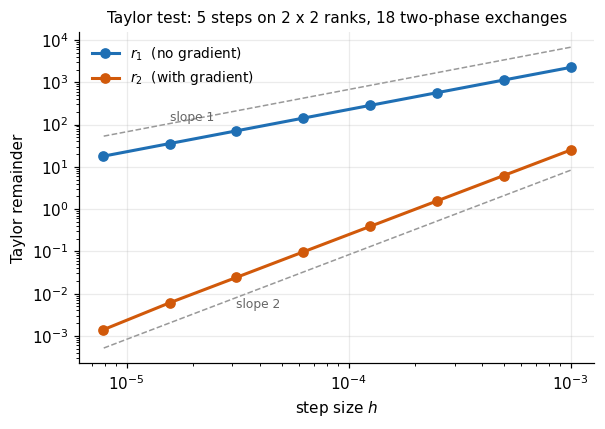

In [23]:
fig, ax = plt.subplots(figsize=(5.6, 4.0))
hs_a = np.array(hs)
ax.loglog(hs_a, r1s, "o-", color=BLUE, lw=2, ms=6, label="$r_1$  (no gradient)")
ax.loglog(hs_a, r2s, "o-", color=ORANGE, lw=2, ms=6, label="$r_2$  (with gradient)")
guide1 = 3.0 * r1s[0] * (hs_a / hs_a[0])            # offset so the guides sit beside the data
guide2 = r2s[0] / 3.0 * (hs_a / hs_a[0]) ** 2
ax.loglog(hs_a, guide1, "--", color="0.6", lw=1, zorder=0)
ax.loglog(hs_a, guide2, "--", color="0.6", lw=1, zorder=0)
ax.annotate("slope 1", (hs_a[-2], guide1[-2]), color="0.4", fontsize=8, va="bottom")
ax.annotate("slope 2", (hs_a[-3], guide2[-3]), color="0.4", fontsize=8, va="top")
ax.set_xlabel("step size $h$")
ax.set_ylabel("Taylor remainder")
ax.set_title(f"Taylor test: {N_STEPS} steps on {DS.Rx} x {DS.Ry} ranks, {3 * (N_STEPS + 1)} two-phase exchanges", fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

Second order, clean until the last halving, where `r₂` has fallen to `1.4 × 10⁻³` against a cost
of `6.4 × 10¹¹` — two parts in `10¹⁵`, the roundoff floor of the cost itself — and the rate
drifts to 2.13. The gradient through eighteen two-phase corner exchanges and their reversed
transposes is right.

Right to what precision, though? The Taylor test has a resolution, and it is worth knowing.
Re-evaluate `r₂` with the *same* stored `J(x + h d)` values but a directional derivative that is
deliberately off by a relative `ε`:

In [24]:
print("rate2 over the seven halvings if <grad J, d> were off by a relative eps:")
for eps in (0.0, 1e-5, 1e-4, 1e-3):
    r2p = [abs(Jh - J0 - h * dJ * (1.0 + eps)) for h, Jh in zip(hs, Jhs)]
    rates = [np.log2(a / b) for a, b in zip(r2p[:-1], r2p[1:])]
    print(f"  eps = {eps:.0e}: " + "  ".join(f"{r:.2f}" for r in rates))

rate2 over the seven halvings if <grad J, d> were off by a relative eps:
  eps = 0e+00: 2.00  2.00  2.00  2.00  2.00  2.00  2.13
  eps = 1e-05: 2.00  2.00  1.99  1.99  1.98  1.96  2.04
  eps = 1e-04: 1.99  1.97  1.95  1.91  1.83  1.70  1.61
  eps = 1e-03: 1.88  1.79  1.66  1.49  1.33  1.20  1.12


Rate 2 survives a `10⁻⁵` error in the gradient almost untouched, a `10⁻⁴` error pulls the late
rates down to 1.6–1.8, and `10⁻³` is unmistakable. So over this range of `h` the Taylor test
certifies the gradient to about one part in `10⁴`. The `10⁻¹²` agreement of section 5.4 comes
from the direct comparison against the single-rank gradient, not from here: the Taylor test's job
is to catch a *wrong* gradient, the direct comparison's job is to measure a right one.

## 6. Where these patterns live in real libraries

Every object in `halo_lib` has a name in a production library, and the adjoint question turns
up in each of them in the same form.

**GHEX.** [ghex-org/GHEX](https://github.com/ghex-org/GHEX) — "Generic exascale-ready library
for halo-exchange operations on variety of grids/meshes" — is the library the GHEX round of this
project used. Its [scope page](https://ghex-org.github.io/GHEX/latest/scope/scope.html) defines
the vocabulary, and it maps one-to-one: a *domain descriptor* "describes a domain" (our
`Decomposition` seen from one rank), a *halo generator* "generates a halo given a domain
descriptor" (our `rows`/`cols` slices), a *communication pattern* "provides application-specific
neighbor connectivity information" (our list of `Message`s), and a *communication object* "is
responsible for executing communications" (our `exchange`). The source tree carries a
`structured` implementation of all four (regular and cubed-sphere grids) and an `unstructured`
one that ships the pattern while leaving domain descriptor and halo generator as concepts the
application supplies; the Python bindings are on PyPI as
[`ghex`](https://pypi.org/project/ghex/). What GHEX does not have is an adjoint. The transpose of
a pattern is a pattern — the same halo descriptors with send and receive roles swapped — but a
communication object *assigns* into the field it is handed, and the reverse exchange must
*accumulate* into interior cells that receive from up to three neighbours. With raw MPI that is an
`Irecv` per neighbour into separate buffers and an add; a library that writes straight into the
field needs an accumulate-on-receive mode, and GHEX's communication object has none. The
scratch trick of section 3 is what one reaches for in that situation, and section 3 is why it
only goes as far as a ring.

**Atlas.** ECMWF's [Atlas](https://github.com/ecmwf/atlas) (Deconinck et al. 2017, *Computer
Physics Communications* 220, [doi:10.1016/j.cpc.2017.07.006](https://doi.org/10.1016/j.cpc.2017.07.006))
provides the parallel data structures for the grid-point components of the IFS on reduced Gaussian
and unstructured grids. ECMWF Technical Memorandum 760
([Wedi et al. 2015](https://www.ecmwf.int/sites/default/files/elibrary/2015/15259-modelling-infrastructure-integrated-forecasting-system-recent-advances-and-future-challenges.pdf))
describes it in this notebook's terms: "Such communication typically happens through thin halos
surrounding every mesh partition, creating an overlap with a neighbouring partition. Atlas provides
routines that expand the mesh partitions with these halos and provides communication patterns to
update fields in the halos with values from neighbouring partitions" — and on periodicity, "With
periodic halos the periodic boundary is treated exactly like any other internal boundary between
different partitions. The partitions involving the poles are periodic with themselves", which is
exactly how `halo_lib` treats the wrap-around. The class is
[`atlas::parallel::HaloExchange`](https://github.com/ecmwf/atlas/blob/develop/src/atlas/parallel/HaloExchange.h),
and next to `execute` it has **`execute_adjoint`**: the body packs the *halo* into the buffer
the forward pass receives into, sends it in the reverse direction, unpacks it into the region the
forward pass sends from, and ends with `zero_halos` — every message reversed, the halo cotangent
zeroed after it has been sent: section 2.2's rule, in a production library.
IFS-FVM, the finite-volume dynamical core, runs on it: "the mesh generation and mesh data
structures, as well as the nearest-neighbour distributed-memory communication using MPI, are
handled by ECMWF's Atlas library" ([Kühnlein et al. 2019](https://doi.org/10.5194/gmd-12-651-2019),
*Geosci. Model Dev.* 12).

**The IFS dynamics do not exchange halos at all.** The operational dynamical core is
spectral-transform, and its parallel structure is a **transposition**, not a halo: between
grid-point, Fourier and spectral space the whole field changes decomposition, so every element
moves, and the communication is all-to-all within subsets of ranks. IFS Documentation Cy49r1
[Part VI](https://www.ecmwf.int/sites/default/files/elibrary/112024/81628-ifs-documentation-cy49r1-part-vi-technical-and-computational-procedures.pdf),
§2.1.3(a): "the transpose steps involve moving data between processors to form a new decomposition,
which enables the following transform or computational step to perform its calculations with all
a node's data dependencies satisfied within that node", and "transpositions never involve global
communication, but only communication within each subset". The transforms live in
[ecTrans](https://github.com/ecmwf-ifs/ectrans); the transposition routines
(`src/trans/cpu/internal/`) are `TRGTOL`/`TRLTOG` between grid-point and Fourier space, built on
`MPL_SEND`/`MPL_RECV`, and `TRLTOM`/`TRMTOL` between Fourier and spectral space, built on
`MPL_ALLTOALLV`. The adjoint of a transposition is the same transposition run the other way, and
ecTrans does literally that: the adjoint transform drivers `ltinv_ctlad` and `ltdir_ctlad` call
the *forward* `TRLTOM` and `TRMTOL` in the opposite direction, and only the pack/unpack kernels
have adjoint variants (`trltomad_pack_unpack.F90`, `trmtolad_pack_unpack.F90` in the GPU tree).

**The semi-Lagrangian advection does, and its halo is wide.** Grid-point advection needs data
from wherever the departure point lands, so the halo is sized by the largest wind the model might
ever see. Part VI §2.2.4: "The grid-column data that could potentially be required on a
processor from neighbouring processors (called the halo) is calculated from the model time step
TSTEP and a conservative estimate of the global maximum wind likely to be encountered (VMAX2
(m/sec)). Typical values for VMAX2 are 150-200 m/sec." Memorandum 760 names the cost: "relatively
large halos are allocated which are derived from a maximum expected wind speed and the model
time-step. The resulting halo area is therefore of constant size" — it does not shrink with the
rank count. The remedy is *on-demand* communication. `SLCOMM1` "communicates the full halo before
the departure point calculations", and `SLCOMM2A` "uses an 'on-demand' scheme to communicate only
the required halo points for fields used in the interpolations", in two steps: "firstly a list of
points required by 'the processor' is communicated to the surrounding processors, and then the
required points are communicated back". [ECMWF Newsletter 173](https://www.ecmwf.int/en/newsletter/173/earth-system-science/new-way-computing-semi-lagrangian-advection-ifs)
(Diamantakis & Váňa, 2022), which describes a new SETTLS-based iteration for the departure points
ported into the IFS — Atlas appears there only in preliminary ESCAPE-dwarf experiments — proposes
going further with "alternative 'thin halo' communication on-demand approaches, which will reduce the
memory and communication cost" — a proposal in that article, not a delivered scheme.

**And the adjoint is the same operation every time.** Semi-Lagrangian interpolation is a gather:
each arrival point reads a stencil around its departure point. Its transpose is a scatter-add into
that stencil (Polavarapu, Tanguay, Ménard & Staniforth 1996, "The tangent linear model for
semi-Lagrangian schemes: linearizing the process of interpolation", *Tellus A* 48,
[doi:10.3402/tellusa.v48i1.11633](https://doi.org/10.3402/tellusa.v48i1.11633); Tanguay &
Polavarapu 1999, "The Adjoint of the Semi-Lagrangian Treatment of the Passive Tracer Equation",
*Mon. Wea. Rev.* 127), and when the stencil reaches into the halo the adjoint accumulates into a
neighbour's interior — the reverse exchange of this notebook, through a wind-sized halo. The IFS
tangent-linear and adjoint models carry the semi-Lagrangian scheme with them: the departure-point
algorithm is "applied consistently to the nonlinear forecast, tangent linear, and adjoint
models" (Diamantakis & Magnusson 2016, *Mon. Wea. Rev.* 144,
[doi:10.1175/MWR-D-15-0432.1](https://doi.org/10.1175/MWR-D-15-0432.1)).

| component | forward communication | its adjoint |
|---|---|---|
| spectral dynamics (ecTrans) | transposition: all-to-all within subsets, every element moves | the transposition run backwards |
| grid-point stencils (Atlas, GHEX, ICON, `halo_lib`) | thin nearest-neighbour halo fill | scatter-accumulate into the owners, halo zeroed |
| semi-Lagrangian advection (IFS `SLCOMM1`/`SLCOMM2A`) | wide halo, sized by max wind × Δt, filled on demand | scatter-accumulate through the same wide halo |

Spectral means transposes, not halos. Grid-point means halos — thin ones for stencils, a
wind-sized one for advection. And in every row the adjoint of the data movement is its transpose,
which for a halo fill is the scatter-accumulate this notebook has been testing. (ICON, for
completeness: `src/parallel_infrastructure/mo_communication.f90` in the
[public ICON repository](https://gitlab.dkrz.de/icon/icon-model) does "data exchange according
to a communication pattern" through `exchange_data`, with a YAXT backend alongside — the same
pattern/communicator split as GHEX — and `exchange_data` takes an optional `add` argument, so
add-on-receive, the piece GHEX lacks, is there.)

## 7. Summary, and where this sits in the series

| forward (2-D halo fill) | adjoint (2-D reverse exchange) |
|---|---|
| phase `x` faces, then phase `y` extended columns | phase `y` first, then phase `x` — **reversed** |
| corner rides in the second phase inside the extended column | corner cotangent leaves in the *first* reverse phase and is forwarded by the second |
| `halo = owner` | `owner_bar += halo_bar` |
| old halo contents discarded | `halo_bar = 0` after sending |
| one interior corner cell feeds 3 ranks | one interior corner cell collects 3 cotangents |
| scratch trick: exact on a ring with `mloc ≥ 2h` | scratch trick: drops the corner cotangent, delivers each corner-adjacent face cotangent three times |

- **`nb01`** derived this transpose inside one array with `concat_where`; the `4 / 2 / 1` fan-out
  matrix of section 2.1 is its "row sums of `L^T`" in 2-D, and the reversed-phase corner path is
  what `nb01` §6 observed when reverse mode replayed the `J` stages before the `I` stages.
- **`nb02`** is Route B, `custom_vjp` around an opaque exchange; section 5 is that route with a
  2-D pattern and real corners, and `halo_lib` is the shape of what the MPI backward has to do.
- **`nb03`** found that GSPMD emits a correct two-phase corner exchange for a nine-point stencil
  on a 2-D mesh, composing a row shift with a column shift. That is exactly `two_phase_pattern`,
  and its transpose — which JAX derives — is exactly `exchange_adjoint`.
- **The GHEX round** decomposed in 1-D because its reverse exchange reused the forward pattern
  on a scratch buffer. Section 3 is the proof that this was necessary, not cautious: the trick
  is the transpose of a face-only exchange and nothing else. A 2-D GHEX adjoint needs a real
  reversed pattern — the same halo descriptors with send and receive roles swapped, which is
  the easy part — plus accumulate-on-receive, which GHEX's communication object does not offer,
  ICON's `exchange_data` has as an `add` flag, and Atlas folds into `execute_adjoint`.